# Installation

In [ ]:
!pip install git+https://github.com/borongzhang/magpie_ptychography.git@main

# Imports

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import h5py
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import imageio.v2 as imageio
import random
import time
from magpie_ptychography.src import magpie_loop, rpie, lbfgs
from magpie_ptychography.src import feasibility_distance_misfit
from magpie_ptychography.src import generate_intensity_measurements, generate_scanning_positions


# Setup

In [2]:
# Size of the object
object_shape = (512, 512)

# Side length of the probe
n_probe = 128


## Realistic Synthetic Object and Probe

In [3]:
mat_data = scipy.io.loadmat('assets/recon_zoneplate_Yi.mat')
obj = mat_data['obj']
orgn_probe = mat_data['probe']

pad_x = (object_shape[0] - obj.shape[0]) // 2
pad_y = (object_shape[1] - obj.shape[1]) // 2

# Pad the object to the desired shape
real_object = np.pad(obj, ((pad_x, pad_x), (pad_y, pad_y)), mode='edge')

ratio = orgn_probe.shape[0] // n_probe

real_probe = orgn_probe[::ratio,::ratio]

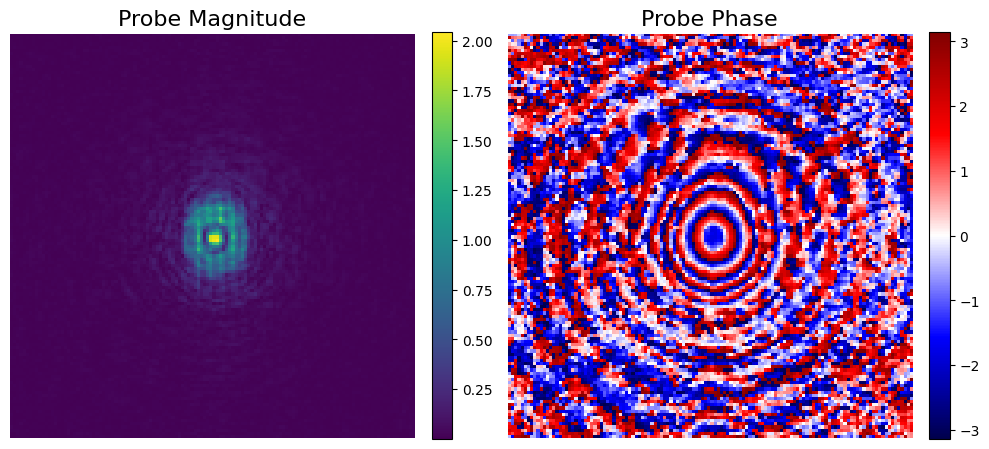

In [4]:
# Compute magnitude and phase
magnitude = np.abs(real_probe)
phase = np.angle(real_probe)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Probe Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='seismic')
ax.set_title('Probe Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('probe_mag_phase.png', dpi=120, bbox_inches='tight')
plt.show()

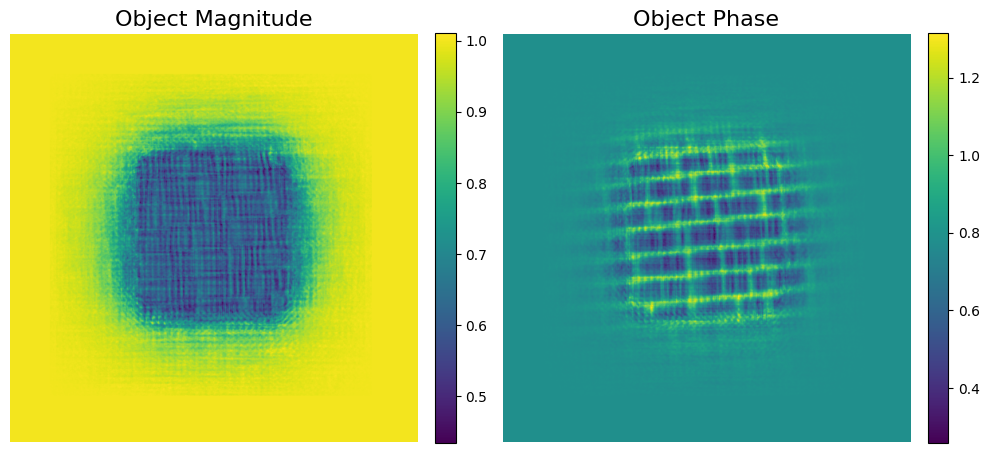

In [5]:
magnitude = np.abs(real_object)
phase = np.angle(real_object)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Object Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='viridis')
ax.set_title('Object Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('realistic_object.png', dpi=120, bbox_inches='tight')
plt.show()

## Data Generation

In [6]:
# Choose Object
probe = real_probe
ground_truth = real_object

# Probe shift for intensity measurement
shift_o50 = 64
shift_o75 = 32

# Define scanning positions
pos_array_o50 = generate_scanning_positions(object_shape, n_probe, shift_o50)
pos_array_o75 = generate_scanning_positions(object_shape, n_probe, shift_o75)

# Noise added to the measurement
noise_level = 0.00

# Generate the data
data_o50 = generate_intensity_measurements(ground_truth, probe, pos_array_o50, noise_level)
data_o75 = generate_intensity_measurements(ground_truth, probe, pos_array_o75, noise_level)


# Numerical examples

In [7]:
misfit = feasibility_distance_misfit
z_initial = np.ones_like(ground_truth)
num_iterations = 3000
alpha_rpie_o50 = 0.03
tol_o50 = 3e-5
alpha_rpie_o75 = 0.06
tol_o75 = 6e-5
print('The maximum level for MAGPIE is:', int(np.log2(probe.shape[0])))


The maximum level for MAGPIE is: 7


In [9]:
z_recon_rPIE_o50, res_rPIE_o50, errors_rPIE_o50, tol_rPIE_o50 = rpie(z_initial, probe, data_o50, pos_array_o50, 
                                                num_iterations, misfit, ground_truth,
                                                alpha = alpha_rpie_o50, metric = True, tol = tol_o50)


In [10]:
z_recon_rPIE_o75, res_rPIE_o75, errors_rPIE_o75, tol_rPIE_o75 = rpie(z_initial, probe, data_o75, pos_array_o75, 
                                                num_iterations, misfit, ground_truth,
                                                alpha = alpha_rpie_o75, metric = True, tol = tol_o75)


In [11]:
z_recon_MAGPIE_o50, res_MAGPIE_o50, errors_MAGPIE_o50, tol_MAGPIE_o50 = magpie_loop(z_initial, probe, data_o50, pos_array_o50, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie_o50, metric = True, tol = tol_o50, 
                                                   max_level = int(np.log2(probe.shape[0])))


In [12]:
z_recon_MAGPIE_o75, res_MAGPIE_o75, errors_MAGPIE_o75, tol_MAGPIE_o75 = magpie_loop(z_initial, probe, data_o75, pos_array_o75, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie_o75, metric = True, tol = tol_o75, 
                                                   max_level = int(np.log2(probe.shape[0])))


In [13]:
zstar_o50, eval_history_LBFGS_o50, tol_LBFGS_o50 = lbfgs(z_initial, probe, data_o50, pos_array_o50, 
                                                   num_iterations, misfit, ground_truth, tol = tol_o50)


In [14]:
zstar_o75, eval_history_LBFGS_o75, tol_LBFGS_o75 = lbfgs(z_initial, probe, data_o75, pos_array_o75, 
                                                   num_iterations, misfit, ground_truth, tol = tol_o75)


In [15]:
res_f_LBFGS_o75 = eval_history_LBFGS_o75['f']
errors_LBFGS_o75 = eval_history_LBFGS_o75['error']
res_f_LBFGS_o50 = eval_history_LBFGS_o50['f']
errors_LBFGS_o50 = eval_history_LBFGS_o50['error']

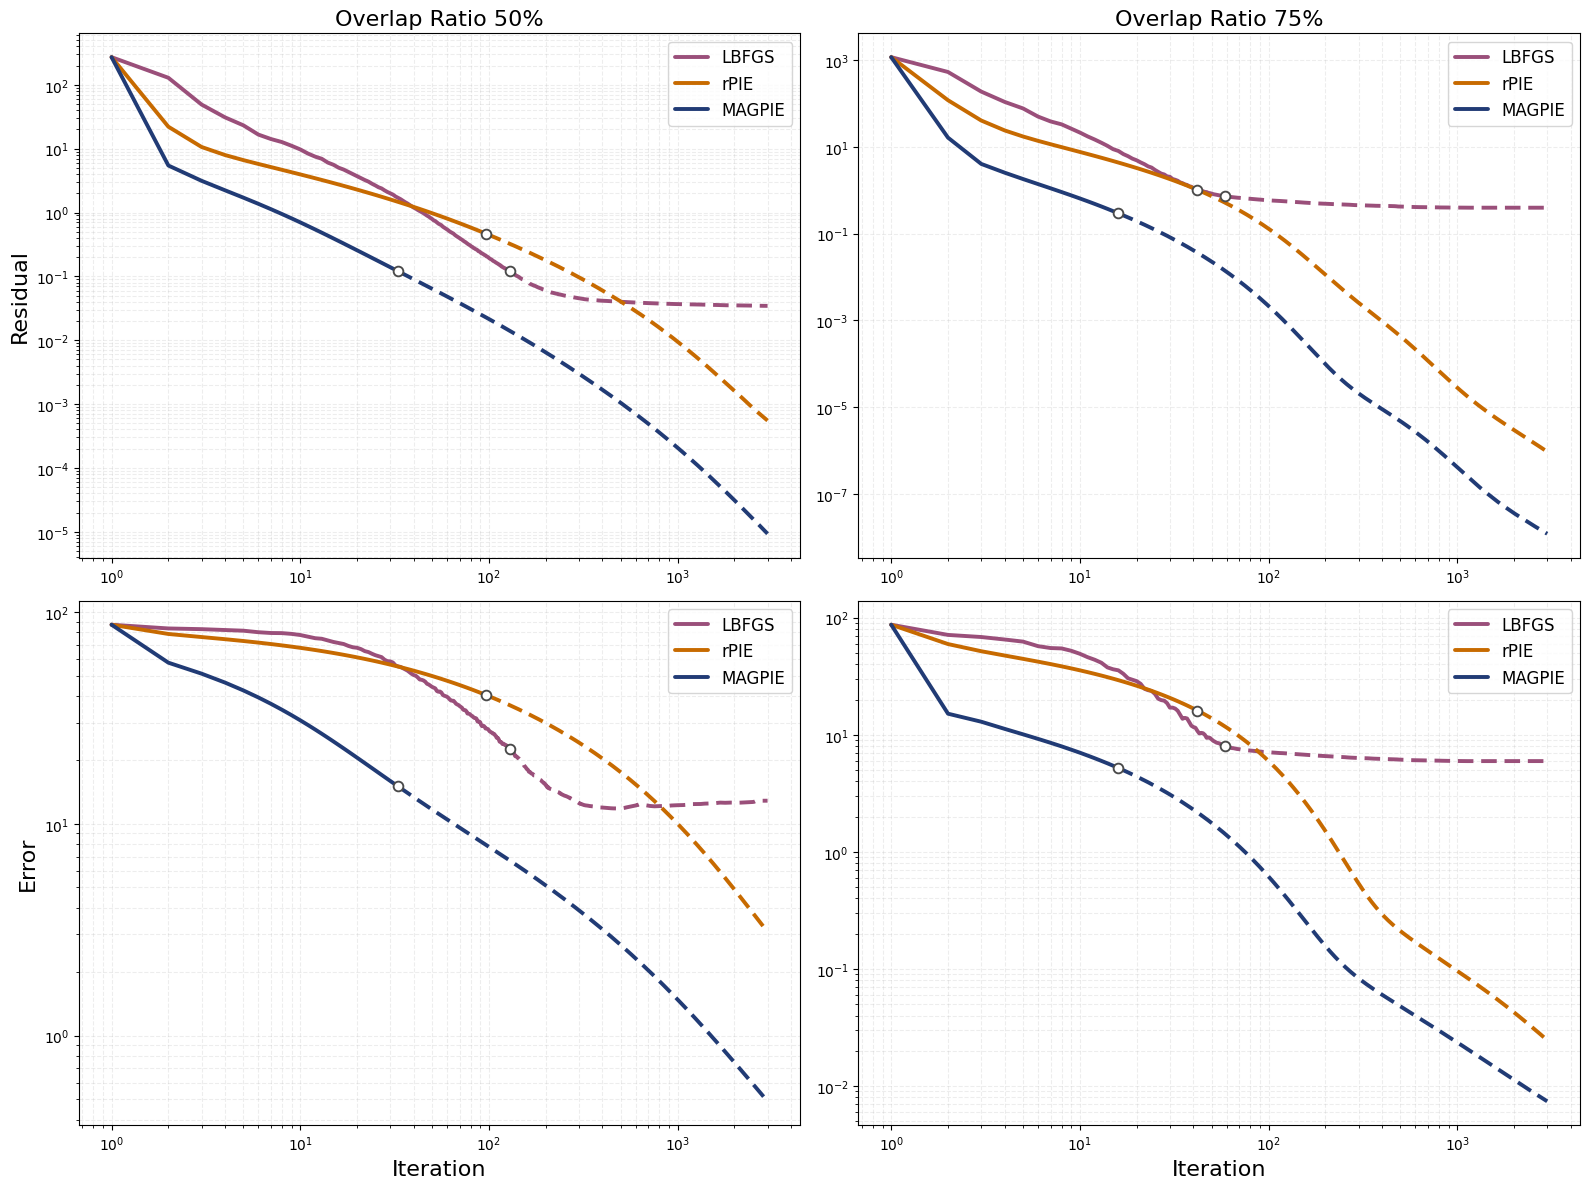

In [16]:
lbfgs_color = '#9A4F7A'
rpie_color  = '#C76A00'
magpie_color = '#213B75'

def plot_curve_with_tol(ax, values, tol_iter, label, color, lw=2.8):
    values = np.asarray(values)

    # x=1 is the initial point, x=j+1 corresponds to iteration j
    x = np.arange(1, len(values) + 1)
    y = values

    if len(x) == 0:
        return

    tol_x = None if tol_iter is None else int(tol_iter) + 1

    if tol_x is None or tol_x < 1 or tol_x > len(values):
        ax.plot(
            x, y,
            label=label,
            color=color,
            linewidth=lw,
            linestyle='-',
            solid_capstyle='round'
        )
        return

    mask_before = x <= tol_x
    mask_after  = x >= tol_x

    ax.plot(
        x[mask_before], y[mask_before],
        label=label,
        color=color,
        linewidth=lw,
        linestyle='-',
        solid_capstyle='round'
    )

    ax.plot(
        x[mask_after], y[mask_after],
        color=color,
        linewidth=lw,
        linestyle=(0, (4, 2)),
        solid_capstyle='round'
    )

    ax.plot(
        tol_x, y[tol_x - 1],
        marker='o',
        markersize=7.0,
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor='#4A4A4A',
        markeredgewidth=1.35,
        zorder=10
    )

def plot_subfigure(ax,
                   values_lbfgs, values_rpie, values_magpie,
                   tol_lbfgs, tol_rpie, tol_magpie,
                   overlap_ratio=None,
                   xlabel=True, ylabel=False):
    plot_curve_with_tol(ax, values_lbfgs, tol_lbfgs, 'LBFGS',  lbfgs_color, lw=2.8)
    plot_curve_with_tol(ax, values_rpie,  tol_rpie,  'rPIE',   rpie_color,  lw=2.8)
    plot_curve_with_tol(ax, values_magpie, tol_magpie, 'MAGPIE', magpie_color, lw=2.8)

    if xlabel:
        ax.set_xlabel('Iteration', fontsize=16)

    if ylabel == 1:
        ax.set_ylabel('Residual', fontsize=16)
    elif ylabel == 2:
        ax.set_ylabel('Error', fontsize=16)

    if overlap_ratio is not None:
        ax.set_title(f'Overlap Ratio {overlap_ratio}%', fontsize=16)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', linestyle='--', alpha=0.22)
    ax.legend(fontsize=12, frameon=True, loc='best')


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

plot_subfigure(
    axes[0, 0],
    res_f_LBFGS_o50, res_rPIE_o50, res_MAGPIE_o50,
    tol_LBFGS_o50,   tol_rPIE_o50, tol_MAGPIE_o50,
    overlap_ratio=50,
    xlabel=False,
    ylabel=1
)

plot_subfigure(
    axes[0, 1],
    res_f_LBFGS_o75, res_rPIE_o75, res_MAGPIE_o75,
    tol_LBFGS_o75,   tol_rPIE_o75, tol_MAGPIE_o75,
    overlap_ratio=75,
    xlabel=False,
    ylabel=False
)

plot_subfigure(
    axes[1, 0],
    errors_LBFGS_o50, errors_rPIE_o50, errors_MAGPIE_o50,
    tol_LBFGS_o50,    tol_rPIE_o50,    tol_MAGPIE_o50,
    overlap_ratio=None,
    xlabel=True,
    ylabel=2
)

plot_subfigure(
    axes[1, 1],
    errors_LBFGS_o75, errors_rPIE_o75, errors_MAGPIE_o75,
    tol_LBFGS_o75,    tol_rPIE_o75,    tol_MAGPIE_o75,
    overlap_ratio=None,
    xlabel=True,
    ylabel=False
)

plt.tight_layout()
plt.savefig('metric_4_noiseless.png', dpi=200, bbox_inches='tight')
plt.show()
